# What the PhD gave the Footy Tipper

**A methods-transfer study.** Whether the thinking in the *From Samples to Sensors*
thesis, in particular Study 1's constrained diffusion and the evaluation framework
built around it, can improve the NRL prediction engine. And, honestly, where it cannot.

> **Short answer.** The diffusion model is a dud here. The **evaluation framework**
> around it is the revelation, and porting it immediately produced findings the system
> had no way to see before, including one that says a change made on thesis reasoning
> cost accuracy (section 8).

This notebook is both an engineering record of what changed and evidence that the
thesis methodology transfers to a domain it was never designed for.

---

### The one sentence that motivated all of it

`simulate_game` drew **100,000 samples per match and kept three integers.**

Every proper scoring rule in the repository, log loss, Brier, and Poisson deviance,
scored the **binary win probability**. Nothing scored the score distribution, the
margin distribution, or the draw probability. So the shared Poisson component
`lambda3`, the per-side negative-binomial dispersion, and the ridge market-score
blends were all **unfalsifiable**: they could be arbitrarily wrong and no gate in
the system would notice.

The thesis has a fully worked apparatus for exactly this situation, samples from a
predictive distribution and the question "is it any good", and porting it was nearly
free because the samples already existed.

### Provenance

Every number below is read from `reports/eval-latest.json`, never typed by hand.

| Field | Value |
|---|---|
| Evaluation | Honest nested season-out, meta-layer never sees the test season |
| Held-out seasons | 2024, 2025, 2026 |
| Pooled non-draw games | 580 |
| Predictors | 611 |
| Repo commit | `c0d21863b4` |
| Generated | 2026-07-29 21:52:22 UTC |

In [1]:
import json, pathlib, sys
import numpy as np

PROJECT_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "research" else pathlib.Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# The shipped module, not a reimplementation: every demo below exercises the
# same code the production evaluation runs.
from pipeline.common.model_training import distributional_metrics as dm
from pipeline.common.model_prediciton import prediction_functions as pf

REPORT = json.loads((PROJECT_ROOT / "reports" / "eval-latest.json").read_text())
POOLED = REPORT["pooled"]
MARGIN = POOLED["margin_distribution"]
METHODS = MARGIN["methods"]
SEASONS = REPORT["seasons"]
ORDER = sorted(METHODS, key=lambda k: METHODS[k]["crps"])

print(f"{POOLED['games']} pooled non-draw games over {[s['year'] for s in SEASONS]}")
print(f"accuracy {POOLED['accuracy']:.1%}  log loss {POOLED['log_loss']:.4f}  Brier {POOLED['brier']:.4f}")

import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "font.family": "sans-serif",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlecolor": INK, "axes.labelcolor": INK_2, "axes.edgecolor": GRID,
    "axes.linewidth": 0.8, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.7, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "legend.frameon": False, "figure.dpi": 130,
})


def tidy(ax, xgrid=True, ygrid=False):
    """Recessive chrome: hairline grid on one axis, no box."""
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.xaxis.grid(xgrid); ax.yaxis.grid(ygrid)
    ax.set_axisbelow(True)
    return ax

580 pooled non-draw games over [2024, 2025, 2026]
accuracy 64.5%  log loss 0.6327  Brier 0.2213


---
## 1. The two systems, side by side

The transfer argument turns entirely on **the shape of the thing being predicted**.
This is why the diffusion does not come across, and why the metric suite does.

|  | PhD Study 1 | Footy Tipper |
|:--|:--|:--|
| Observed | Meter read total `r` over an interval | Pre-game features |
| Predicted | **Up to 160 daily values** | **A 2-vector: home and away score** |
| Hard constraint | `sum(daily) = r` exactly | None; scores need not sum to anything |
| Generator | Conditional diffusion, 200 denoise steps | Poisson / negative-binomial sampler |
| Posterior size | 30 sampled histories | 100,000 sampled scorelines |
| What makes it hard | **Joint** structure across days | Getting one number calibrated |
| Scored with | CRPS, energy, variogram, coverage, PIT | Log loss and Brier, on the tip only |

The diffusion earns its keep by sculpting a **coherent 160-day trajectory**: weekend
rhythms, dry spells, and wet weeks emerging as joint structure the day-by-day
quantile GBM structurally cannot produce.

A rugby league match has **two numbers**. There is no joint structure to model. A
score network over two dimensions is not a hard problem badly solved, it is a
category error. The strongest evidence is the thesis's own honest negative: on the
problem the diffusion *was* designed for, a simple empirical replay lookup beat it
on every whole-history realism metric and merely tied it on CRPS.

What survives the shape difference is everything that was never about the shape:
**how you know whether a predictive distribution is any good.**

---
## 2. What transfers, and what does not

| Thesis technique | Verdict | Why |
|:--|:-:|:--|
| CRPS on ensemble samples | **Ported** | Samples already drawn; accuracy and honesty in one number |
| Coverage reported with width | **Ported** | No predictive intervals existed at all |
| Randomised PIT | **Ported, adapted** | Margins are integers, so the plain PIT is wrong (section 4) |
| Strong baselines, not a floor | **Ported** | Empirical replay was the thesis bar; here it is a normal approximation |
| Constraint-native over projection | **Ported, at a price** | Replaced post-hoc reweighting; more coherent, less accurate (sections 5, 8) |
| Conditional diffusion | Rejected | Output is a 2-vector; no joint structure exists to model |
| Energy / variogram score | Rejected | Multivariate trajectory metrics, degenerate on 2 dims |
| Zero-inflation / hurdle head | Rejected | Rugby scores are not zero-inflated by a separate process |
| Constraint projection | Rejected | There is no aggregation constraint to project onto |
| Clustering front-end | Rejected | Null in the thesis; teams are already categorical features |

The rejections matter as much as the adoptions. The thesis discipline that makes a
negative result publishable is the same discipline that stops a method being ported
because it is impressive rather than because it fits.

---
## 3. Change one: scoring the distribution at all

`pipeline/common/model_training/distributional_metrics.py` is new. The core is the
CRPS estimator from the thesis *Metrics Explained* page:

$$\mathrm{CRPS} = \frac{1}{S}\sum_s |x_s - y| \; - \; \frac{1}{2S^2}\sum_{s}\sum_{s'} |x_s - x_{s'}|$$

CRPS rewards accuracy and honest uncertainty **together**, and it reduces to MAE for
a point forecast, which is exactly what lets deterministic and probabilistic methods
be ranked on one scale.

The double sum is `O(S^2)`. At `S = 100,000` that is 10^10 operations per match, so
it is evaluated through the sorted-sample identity

$$\sum_s\sum_{s'}|x_s - x_{s'}| \;=\; 2\sum_i (2i - S - 1)\, x_{(i)}$$

turning the cost into a sort. The same `1/(2S^2)` convention as the thesis is kept
deliberately, rather than the unbiased `1/(S(S-1))` variant, so numbers stay
comparable across the two projects.

In [2]:
# The estimator is proper: a correctly specified forecast must beat both an
# overconfident and an underconfident one. Without this property CRPS could not
# be used as a gate.
rng = np.random.default_rng(20100308)
truth = rng.normal(0.0, 3.0, size=600)

def mean_crps(sigma):
    draws = rng.normal(0.0, sigma, size=40_000)
    return float(np.mean([dm.crps_ensemble(draws, y) for y in truth]))

for label, sigma in [("too narrow (s=0.75)", 0.75), ("HONEST  (s=3.00)", 3.0), ("too wide  (s=9.00)", 9.0)]:
    print(f"{label:22s}  CRPS {mean_crps(sigma):6.3f}")

# And it collapses to MAE when the forecast has no spread.
point = np.full(500, 7.0)
print(f"\npoint forecast 7.0 vs outcome 3.0 -> CRPS {dm.crps_ensemble(point, 3.0):.3f} (= |7-3|)")

too narrow (s=0.75)     CRPS  2.127
HONEST  (s=3.00)        CRPS  1.766
too wide  (s=9.00)      CRPS  2.525

point forecast 7.0 vs outcome 3.0 -> CRPS 4.000 (= |7-3|)


---
## 4. The one genuine technical adaptation: randomised PIT

The Probability Integral Transform asks where the truth fell inside the predicted
distribution. Flat histogram means calibrated; a U-shape means the distribution is
too narrow; a hump means too wide. The thesis uses it to diagnose the diffusion's
under-coverage.

**It cannot be ported unchanged.** Water consumption is continuous; a rugby margin
is an **integer**. For a discrete predictive distribution, `F` jumps at every
attainable value, so the ordinary PIT is lumpy *even when the model is perfect*.
Using it naively would have manufactured a miscalibration finding that was really
just an artefact of counting in whole points.

The fix (Czado et al.) randomises within the jump:

$$u = F(y^-) + v\,\bigl(F(y) - F(y^-)\bigr), \qquad v \sim U(0,1)$$

The demo below is the whole argument: **the same correctly specified Poisson
forecast**, scored both ways.

naive deviation      0.0510  <- looks broken, model is fine
randomised deviation 0.0034  <- correctly flat


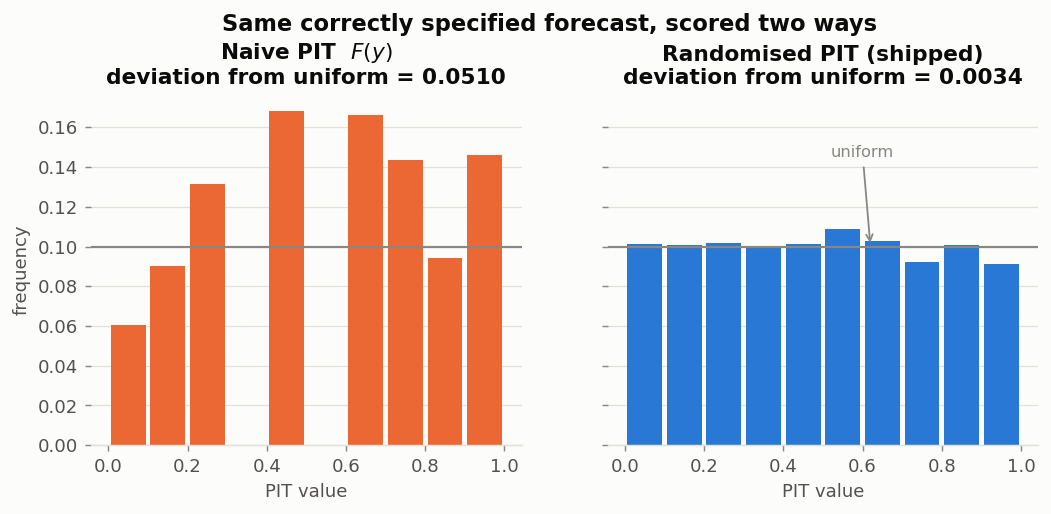

In [3]:
rng = np.random.default_rng(7)
draws = rng.poisson(6.0, size=40_000)     # the forecast
truth = rng.poisson(6.0, size=3_000)      # outcomes from the SAME process

naive = [float(np.mean(draws <= y)) for y in truth]                  # plain F(y)
randomised = [dm.randomised_pit(draws, y, rng=rng) for y in truth]   # shipped

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.5), sharey=True)
for ax, values, colour, name in (
    (axes[0], naive, ORANGE, "Naive PIT  $F(y)$"),
    (axes[1], randomised, BLUE, "Randomised PIT (shipped)"),
):
    hist = dm.pit_histogram(values)
    ax.bar(np.arange(10) / 10 + 0.05, hist["frequencies"], width=0.088,
           color=colour, linewidth=0)
    ax.axhline(0.1, color=MUTED, linewidth=1.2, zorder=3)
    ax.set_title(f"{name}\ndeviation from uniform = {hist['uniformity_mae']:.4f}")
    ax.set_xlabel("PIT value"); tidy(ax, xgrid=False, ygrid=True)
axes[0].set_ylabel("frequency")
axes[1].annotate("uniform", xy=(0.62, 0.1), xytext=(0.52, 0.145), color=MUTED,
                 fontsize=9, arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
fig.suptitle("Same correctly specified forecast, scored two ways", y=1.06,
             fontsize=12.5, fontweight="bold", color=INK)
plt.show()

print(f"naive deviation      {dm.pit_histogram(naive)['uniformity_mae']:.4f}  <- looks broken, model is fine")
print(f"randomised deviation {dm.pit_histogram(randomised)['uniformity_mae']:.4f}  <- correctly flat")

The left panel is a **perfectly calibrated model** that the naive transform makes
look badly miscalibrated. That trap is pinned by a regression test
(`test_naive_pit_on_the_same_discrete_forecast_is_not_uniform`) so nobody can later
"simplify" the randomisation away.

Applied to the real held-out margins, correctly this time:

outer bins 0.278 vs 0.200 expected -> too much mass in the tails
deviation from uniform 0.0162


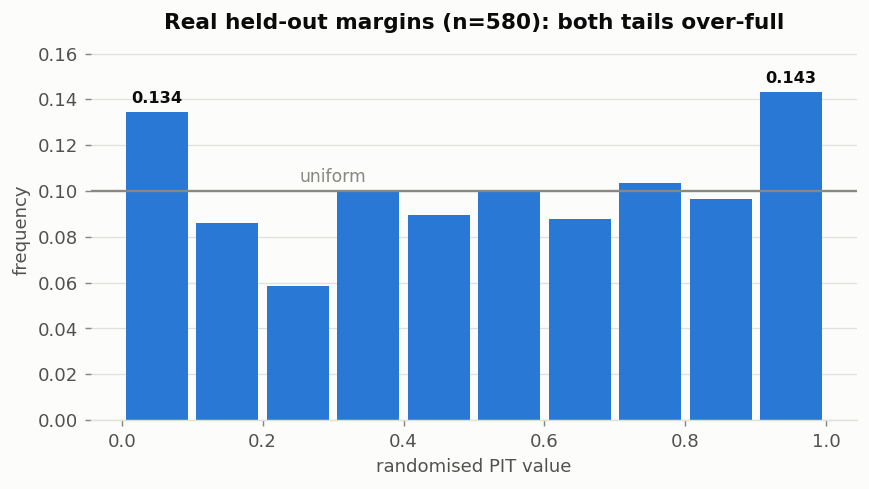

In [4]:
# Pooled across the three held-out seasons, from the persisted report.
counts = np.sum([s["margin_distribution"]["methods"]["model"]["pit"]["counts"]
                 for s in SEASONS], axis=0)
freqs = counts / counts.sum()

fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.bar(np.arange(10) / 10 + 0.05, freqs, width=0.088, color=BLUE, linewidth=0)
ax.axhline(0.1, color=MUTED, linewidth=1.3, zorder=3)
ax.text(0.30, 0.104, "uniform", color=MUTED, fontsize=9.5, ha="center")
for i in (0, 9):
    ax.annotate(f"{freqs[i]:.3f}", xy=(i / 10 + 0.05, freqs[i]),
                xytext=(i / 10 + 0.05, freqs[i] + 0.004), ha="center",
                fontsize=9, color=INK, fontweight="bold")
ax.set_ylim(0, 0.166)
ax.set_xlabel("randomised PIT value"); ax.set_ylabel("frequency")
ax.set_title(f"Real held-out margins (n={counts.sum()}): both tails over-full")
tidy(ax, xgrid=False, ygrid=True)
plt.show()

print(f"outer bins {freqs[0] + freqs[-1]:.3f} vs {2 * 0.1:.3f} expected -> too much mass in the tails")
print(f"deviation from uniform {np.mean(np.abs(freqs - 0.1)):.4f}")

Both outer bins sit above the uniform line: the truth lands in the tails of the
predicted distribution more often than it should. That is the PIT signature of a
distribution that is **slightly too narrow**, and it agrees with the coverage numbers
in section 7 (90% intervals containing 84% of outcomes). The thesis reports the same
signature, more severely, for the diffusion posterior.

---
## 5. Change two: constraint-native coherence

This is where a thesis *idea*, rather than a thesis metric, changed the production code.

Footy Tipper produces its win probability from a calibrated pool of experts, and its
scoreline from a Poisson simulation. **These two disagree.** The old code reconciled
them after the fact with two-point importance weights:

```python
weights[margins > 0] = cal / raw_cond          # old: reweight after simulating
weights[margins < 0] = (1 - cal) / (1 - raw_cond)
```

plus a special case for when calibration tipped a side the simulation never produced.

In the thesis's own vocabulary this is **final-only projection**, and Study 1 already
established that final-only projection distorts the shape of what it corrects. The
structural answer there is a **constraint-native parameterisation**: build the object
so the constraint holds by construction and no projection is ever needed.

Applied here: hold the total `mu_h + mu_a` fixed and **solve for the margin** so the
distribution's own win probability *is* the calibrated one. It works because the
Skellam conditional is monotone in the mean difference at fixed total.

total preserved: 44.000000 (was 44.0)
achieved probability: 0.350000 (target 0.35)


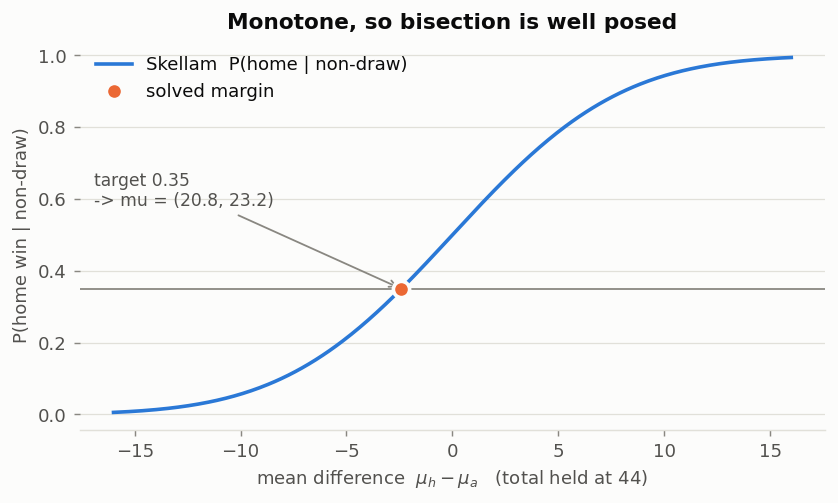

In [5]:
total = 44.0
diffs = np.linspace(-16, 16, 400)
probs = [pf.conditional_home_win_prob((total + d) / 2, (total - d) / 2) for d in diffs]

target = 0.35
mu_h, mu_a = pf.solve_score_means_for_probability(24.0, 20.0, target)

fig, ax = plt.subplots(figsize=(7.4, 3.9))
ax.plot(diffs, probs, color=BLUE, linewidth=2, label="Skellam  P(home | non-draw)")
ax.axhline(target, color=MUTED, linewidth=1, linestyle="-")
ax.plot([mu_h - mu_a], [target], "o", color=ORANGE, markersize=9,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=5, label="solved margin")
ax.annotate(f"target {target:.2f}\n-> mu = ({mu_h:.1f}, {mu_a:.1f})",
            xy=(mu_h - mu_a, target), xytext=(mu_h - mu_a - 14.5, target + 0.23),
            color=INK_2, fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
ax.set_xlabel("mean difference  $\\mu_h - \\mu_a$   (total held at 44)")
ax.set_ylabel("P(home win | non-draw)")
ax.set_title("Monotone, so bisection is well posed")
ax.legend(loc="upper left")
tidy(ax, xgrid=False, ygrid=True)
plt.show()

print(f"total preserved: {mu_h + mu_a:.6f} (was 44.0)")
print(f"achieved probability: {pf.conditional_home_win_prob(mu_h, mu_a):.6f} (target {target})")

Now the two approaches on the same match: raw score means favour the home side
(24-20), but the calibrated pool tips **away** at 0.35.

old  weighted mean margin  -2.32   (shape is the home-leaning one, bent)
new  simulated mean margin  -2.40   (a genuine away-leaning distribution)
new  simulated P(home|non-draw) = 0.4453  vs target 0.35


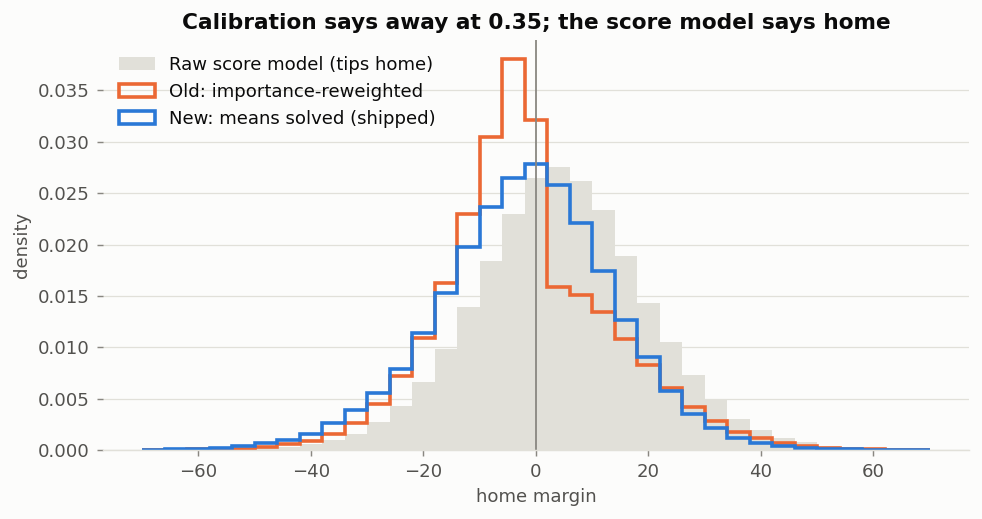

In [6]:
disp_h = SEASONS[-1]["margin_distribution"]["dispersion_home"]
disp_a = SEASONS[-1]["margin_distribution"]["dispersion_away"]
cal = 0.35

# Raw simulation: what the score model alone believes.
h, a = pf.draw_score_samples(24.0, 20.0, 120_000, dispersion_home=disp_h,
                             dispersion_away=disp_a, rng=pf.rng_for_game(1))
raw = h - a

# OLD: keep those samples, bolt weights on afterwards.
raw_cond = (raw > 0).sum() / max(1, (raw > 0).sum() + (raw < 0).sum())
w = np.ones(raw.size)
w[raw > 0] = cal / raw_cond
w[raw < 0] = (1 - cal) / (1 - raw_cond)

# NEW: move the means, then simulate once.
nh, na = pf.solve_score_means_for_probability(24.0, 20.0, cal)
h2, a2 = pf.draw_score_samples(nh, na, 120_000, dispersion_home=disp_h,
                               dispersion_away=disp_a, rng=pf.rng_for_game(1))
new = h2 - a2

bins = np.arange(-70, 71, 4)
fig, ax = plt.subplots(figsize=(8.6, 4.1))
ax.hist(raw, bins=bins, density=True, color=GRID, label="Raw score model (tips home)")
ax.hist(raw, bins=bins, weights=w / w.sum() / 4, histtype="step",
        edgecolor=ORANGE, linewidth=2, label="Old: importance-reweighted")
ax.hist(new, bins=bins, density=True, histtype="step", edgecolor=BLUE,
        linewidth=2, label="New: means solved (shipped)")
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_xlabel("home margin"); ax.set_ylabel("density")
ax.set_title(f"Calibration says away at {cal:.2f}; the score model says home")
ax.legend(loc="upper left")
tidy(ax, xgrid=False, ygrid=True)
plt.show()

print(f"old  weighted mean margin {np.average(raw, weights=w):+6.2f}   (shape is the home-leaning one, bent)")
print(f"new  simulated mean margin {new.mean():+6.2f}   (a genuine away-leaning distribution)")
print(f"new  simulated P(home|non-draw) = {(new > 0).sum() / ((new > 0).sum() + (new < 0).sum()):.4f}  vs target {cal}")

**Look at the orange line at margin zero.** It jumps. That step is the two-point
weight discontinuity made visible: every simulated home win was scaled by one
constant and every away win by another, so the density is torn in half at the
boundary between them. It is the grey distribution with its two halves rescaled, a
home-leaning shape wearing away-leaning weights, and no real predictive distribution
of a rugby margin has a cliff at zero.

The blue is an actual away-leaning distribution, smooth through zero, and it is the
only one of the three that can be sampled from, quantiled, or scored coherently.

Two consequences fell out for free:

- The **mirroring fallback is now unreachable**. Calibration can no longer tip a side
  the simulation never produced, because the means themselves were moved there.
- `lambda3` no longer suppresses the dispersion. The old sampler silently discarded
  the negative-binomial `k` whenever the shared component was non-zero. They now
  compose, with `k` rescaled by `(lam/mu)^2` so the marginal variance still lands on
  `mu + mu^2/k` while the shared component holds the covariance at `lambda3`.

**This is the coherence argument, not an accuracy claim.** Read section 8 before
concluding the change was a win: measured on held-out seasons, the reweighted version
it replaced was slightly *more* accurate on the displayed scoreline and on CRPS. The
trade is real and it is now priced.

---
## 6. Change three: a train/serve skew found on the way

Not a thesis idea, but found by reading the stack with thesis questions in mind
("is the thing being fitted the thing being served?").

`train.py` computed the lineup-marginalised Tier-B probability and then **never used
it**. The pools and calibrator were fitted on the plain, unmarginalised version,
while `inference.py` served the marginalised one. The meta-layer was being fitted on
a different input from the one it receives in production.

`evaluate.py` had the same gap, which meant the honest evaluation was measuring a
stack subtly different from the deployed one. Both now marginalise, through a new
vectorised path that produces bit-identical values to the scalar version while
evaluating the Skellam conditional across all matches at once.

| Tier-B expert | Before | After |
|:--|--:|--:|
| Log loss | 0.6976 | **0.6877** |
| Brier | 0.2410 | **0.2380** |
| Accuracy | 62.2% | **62.4%** |

**Blast radius, stated precisely.** With zero lineup uncertainty the two paths agree
*exactly* (the marginalisation short-circuits), so only matches with real lineup
uncertainty were ever affected. That is the difference between a scary-sounding bug
and a correctly scoped one, and it is pinned by a test.

---
## 7. Results: what the framework found

Scored on 580 held-out non-draw games. Lower CRPS is better; coverage
should match its nominal level.

| Method | CRPS | 50% cov | 90% cov | 90% width | PIT dev |
|:--|--:|--:|--:|--:|--:|
| Baseline: Normal approximation | 10.20 | 0.50 | 0.87 | 55.8 | 0.0177 |
| Baseline: Empirical replay | 10.22 | 0.48 | 0.88 | 56.9 | 0.0181 |
| Score model (Poisson family) | 10.25 | 0.47 | 0.84 | 51.4 | 0.0194 |
| Score model, reconciled | 10.50 | 0.48 | 0.83 | 51.3 | 0.0263 |

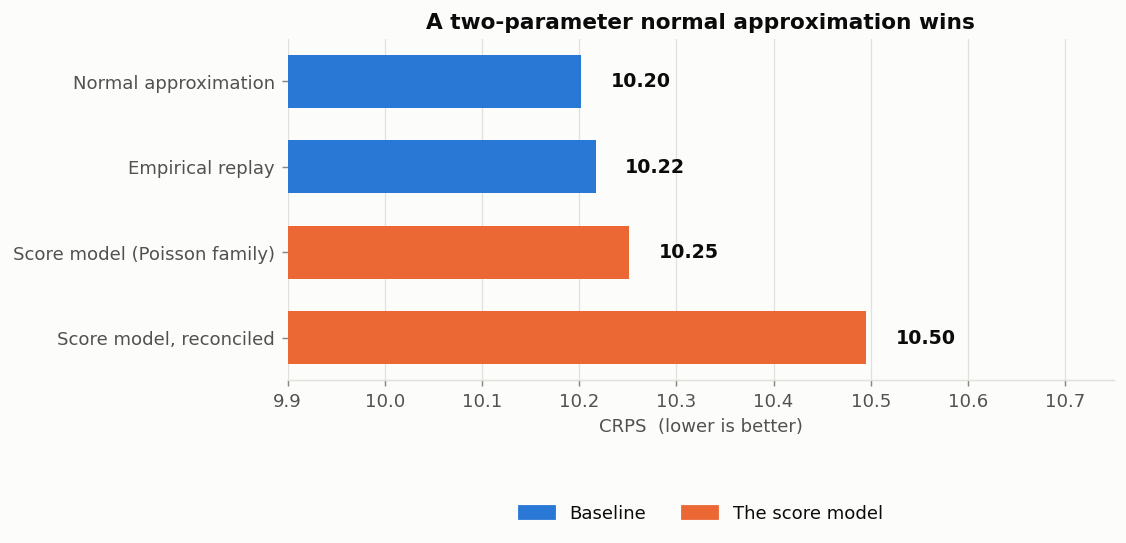

In [7]:
fig, ax = plt.subplots(figsize=(8.2, 3.4))
names = list(reversed(ORDER))                       # best at top
vals = [METHODS[n]["crps"] for n in names]
cols = [ORANGE if not IS_BASELINE[n] else BLUE for n in names]
ax.barh(range(len(names)), vals, color=cols, height=0.62, linewidth=0)
for i, (n, v) in enumerate(zip(names, vals)):
    ax.text(v + 0.03, i, f"{v:.2f}", va="center", color=INK, fontsize=10.5,
            fontweight="bold")
ax.set_yticks(range(len(names)))
ax.set_yticklabels([LABELS[n] for n in names])
ax.set_xlim(9.9, 10.75)
ax.set_xlabel("CRPS  (lower is better)")
ax.set_title("A two-parameter normal approximation wins")
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)]
# Legend below the plot: inside it would collide with the longest bar's label.
ax.legend(handles, ["Baseline", "The score model"], loc="upper center",
          bbox_to_anchor=(0.5, -0.32), ncol=2)
tidy(ax, xgrid=True, ygrid=False)
plt.show()

### Finding one: the simulator does not beat a normal approximation

The 100,000-draw Poisson-family simulator, with its shared component and per-side
negative-binomial dispersion, is **third**, behind a normal fitted to prior-season
residuals with two parameters. The gap is small enough to call a statistical wash,
and that *is* the finding: the machinery is not currently earning its complexity on
distributional accuracy. Before this work there was no way to ask.

This is the thesis's own result shape, replicated in a new domain: in Study 1 a
simple empirical replay matched or beat the constrained diffusion. **Simple, honest
baselines are hard to beat**, and a framework that cannot embarrass its own model is
not an evaluation.

### Finding two: coherence has a measurable price

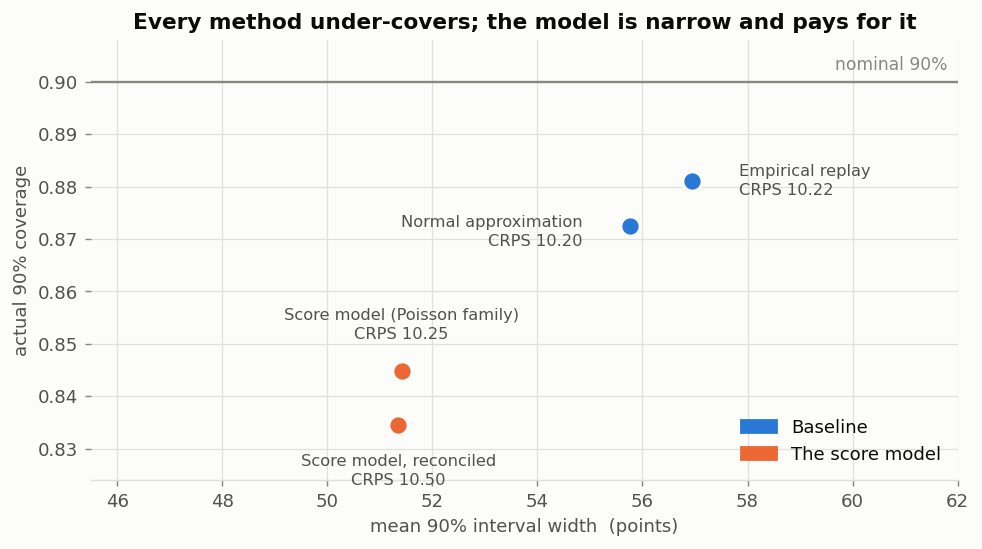

In [8]:
# Explicit per-point label placement: the four points sit in two tight pairs,
# so automatic offsets collide.
PLACE = {
    "normal_approximation": (-0.9, -0.001, "right", "center"),
    "empirical_replay": (0.9, 0.000, "left", "center"),
    "model": (0.0, 0.0055, "center", "bottom"),
    "model_reconciled": (0.0, -0.0055, "center", "top"),
}

fig, ax = plt.subplots(figsize=(8.6, 4.4))
for name in ORDER:
    x = level_of(name, 0.9, "width"); y = level_of(name, 0.9, "coverage")
    colour = BLUE if IS_BASELINE[name] else ORANGE
    dx, dy, ha, va = PLACE[name]
    ax.plot([x], [y], "o", color=colour, markersize=11, markeredgecolor=SURFACE,
            markeredgewidth=2, zorder=4)
    ax.annotate(f"{LABELS[name]}\nCRPS {METHODS[name]['crps']:.2f}",
                xy=(x, y), xytext=(x + dx, y + dy), ha=ha, va=va,
                fontsize=9, color=INK_2, linespacing=1.35)
ax.axhline(0.9, color=MUTED, linewidth=1.3)
ax.text(61.8, 0.9022, "nominal 90%", color=MUTED, fontsize=9.5, ha="right")
ax.set_xlim(45.5, 62); ax.set_ylim(0.824, 0.908)
ax.set_xlabel("mean 90% interval width  (points)")
ax.set_ylabel("actual 90% coverage")
ax.set_title("Every method under-covers; the model is narrow and pays for it")
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)]
ax.legend(handles, ["Baseline", "The score model"], loc="lower right")
tidy(ax, xgrid=True, ygrid=True)
plt.show()

Reconciling the score means onto the calibrated win probability, which is **what
actually ships**, costs CRPS (10.25 to
10.50) and worsens PIT deviation
(0.0194 to
0.0263). The win-probability stack
and the score model genuinely disagree, and the
price of making them agree is now a measured quantity rather than an assumption.

That is not an argument against shipping the reconciled version. A tip that
contradicted its own predicted scoreline would be worse than useless to a human
reader. It is an argument for **knowing the cost**, which is exactly what the thesis
insists on with its coverage-versus-CRPS adoption gates.

Note also that every method under-covers at 90%. This is the same signature the
thesis reports for the diffusion posterior (68% at nominal 90%), less severe here,
and the same direction.

### Finding three: the Poisson assumption was badly wrong

Two parameters that had never been checked, now visible per season:

season   lambda3   disp_home   disp_away
  2024     0.000      5.26        4.43
  2025     0.000      5.25        4.43
  2026     0.000      5.19        4.40

Poisson variance 22  vs  fitted NB variance 115
lambda3 = 0 in every season: the shared component contributes nothing.


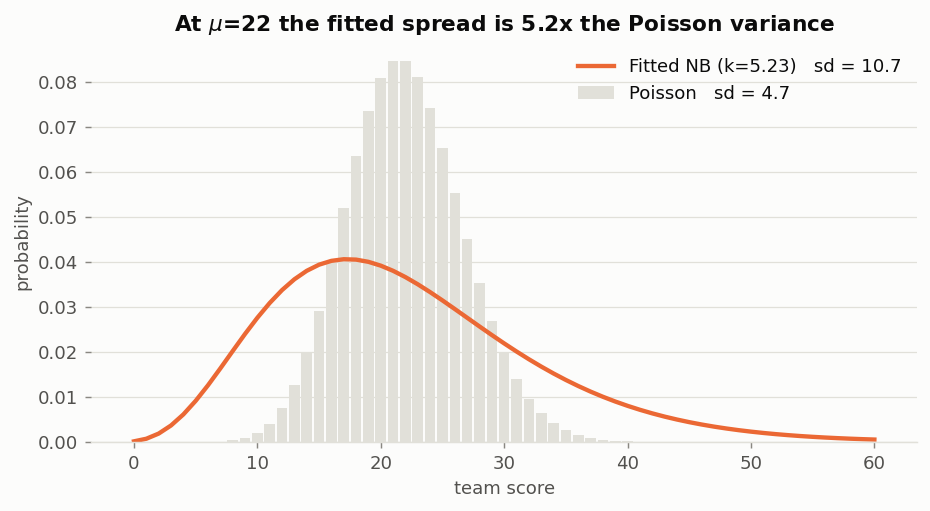

In [9]:
rows = [(s["year"], s["margin_distribution"]) for s in SEASONS]
print("season   lambda3   disp_home   disp_away")
for year, md_ in rows:
    print(f"  {year}     {md_['lambda3']:.3f}      {md_['dispersion_home']:.2f}        {md_['dispersion_away']:.2f}")

from scipy.stats import nbinom, poisson as pois
mu = 22.0
k = float(np.mean([md_["dispersion_home"] for _, md_ in rows]))
nb_var = mu + mu**2 / k

x = np.arange(0, 61)
fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.bar(x, pois.pmf(x, mu), width=0.86, color=GRID,
       label=f"Poisson   sd = {np.sqrt(mu):.1f}")
ax.plot(x, nbinom.pmf(x, k, k / (k + mu)), color=ORANGE, linewidth=2.4,
        label=f"Fitted NB (k={k:.2f})   sd = {np.sqrt(nb_var):.1f}")
ax.set_xlabel("team score"); ax.set_ylabel("probability")
ax.set_title(f"At $\\mu$=22 the fitted spread is {nb_var / mu:.1f}x the Poisson variance")
ax.legend()
tidy(ax, xgrid=False, ygrid=True)
plt.show()

print(f"\nPoisson variance {mu:.0f}  vs  fitted NB variance {nb_var:.0f}")
print("lambda3 = 0 in every season: the shared component contributes nothing.")

Two things were true the whole time and nobody could see either:

- **`lambda3 = 0.0` in all three seasons.** The bivariate shared component, a
  documented feature of the system, is switched off by its own estimator.
- **Dispersion is severe.** The fitted `k` implies roughly five times the Poisson
  variance. Rugby league points arrive in lumps of 2, 4, and 6, so plain Poisson was
  never defensible, and the negative-binomial correction is doing heavy lifting that
  had never been validated.

Neither is a bug. Both are facts about the model that only exist once something
scores the distribution.

Look also at the **left tail** of the fitted negative binomial: it puts real mass
below 10 points, and a fair amount below 5. NRL teams almost never score that low.
So the dispersion correction buys the wide margins it needs by also inventing
scorelines that do not happen, which is very likely part of why it fails to beat a
normal approximation. This is the direct analogue of the thesis's zero-day and
spike-day realism gaps: a distribution can carry roughly the right variance and
still be the wrong *shape*, and only a distributional diagnostic will say so.

---
## 8. What it did to the scoreline you actually read

Section 7 scored the margin's whole predictive *distribution*. That is not what a
reader sees. What ships to the predictions table is three integers: a home score, an
away score, and their difference. Nothing had ever scored those either, and when
something finally did, the first version of the coherence fix turned out to have made
them **worse**. Two separate mistakes were hiding inside one change.

### The scorecard, on 580 games and identical per-game seeds

| How the three integers are produced | Margin MAE | Home MAE | Away MAE | Total MAE | CRPS |
|:--|--:|--:|--:|--:|--:|
| Reweighted, modal scoreline (the arrangement before any of this) | 14.31 | 10.28 | 9.60 | 14.74 | 10.19 |
| Solve every game, modal scoreline (the first version of the fix) | 14.46 | 10.37 | 9.69 | 14.92 | 10.50 |
| Solve every game, median | 14.49 | 9.40 | 8.93 | 11.41 | 10.50 |
| Solve on conflict, modal scoreline | 14.24 | 10.26 | 9.61 | 14.78 | 10.23 |
| Solve on conflict, median (**deployed**) | 14.12 | 9.24 | 8.76 | 11.36 | 10.23 |

Read the top two rows first. The change described in section 5 moved margin MAE from
**14.31** to **14.46** and CRPS from
**10.19** to **10.50**, worse in every season. A change made
on thesis reasoning, shipped, and costing accuracy. Nothing else in the system would
ever have told me.

### Mistake one: displaying a mode

The displayed scoreline was the most common exact scoreline among the simulated games.
A mode of a two-dimensional discrete distribution is a terrible point estimate, and it
had been the displayed one since long before this work.

modal margins across the sweep : [-5, -4, -3, -2, -1, 1, 2, 3, 4, 8]
median margins across the sweep: [-3, -2, -1, 1, 2, 3]


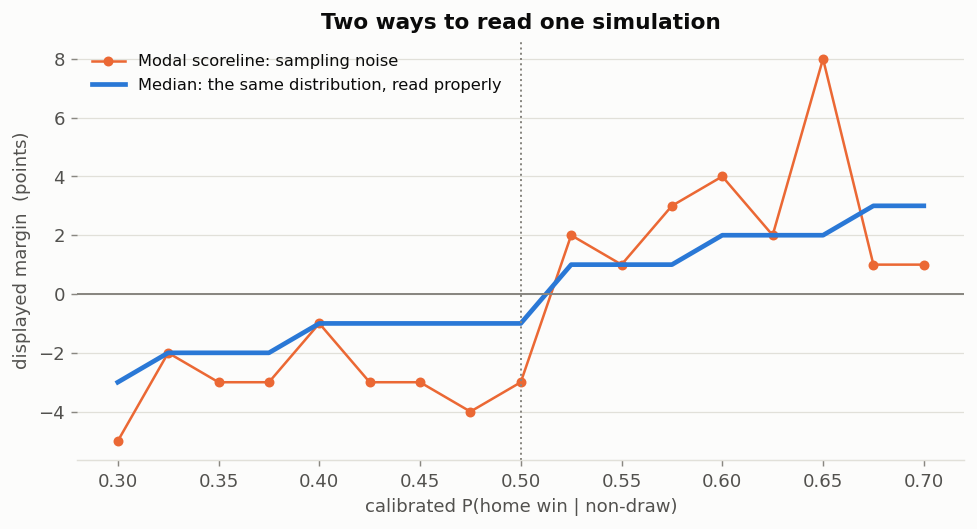

In [10]:
# Same match, same seed, sweeping the calibrated probability. Three numbers:
# what the two displays print, and the median the distribution already knew.
conds = np.round(np.arange(0.30, 0.71, 0.025), 3)
by_mode, by_median = [], []
for cond in conds:
    kwargs = dict(n_simulations=100_000, lambda3=0.0, dispersion_home=5.19,
                  dispersion_away=4.34, calibrated_cond=float(cond), reconcile="always")
    _, sl_mode = pf.simulate_game(22.0, 20.0, rng=pf.rng_for_game(1, salt=1),
                                  display="mode", **kwargs)
    _, sl_median = pf.simulate_game(22.0, 20.0, rng=pf.rng_for_game(1, salt=1),
                                    display="median", **kwargs)
    by_mode.append(sl_mode[0] - sl_mode[1])
    by_median.append(sl_median[0] - sl_median[1])

fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.plot(conds, by_mode, "o-", color=ORANGE, linewidth=1.4, markersize=4.5,
        label="Modal scoreline: sampling noise")
ax.plot(conds, by_median, color=BLUE, linewidth=2.6,
        label="Median: the same distribution, read properly")
ax.axhline(0, color=MUTED, linewidth=1.1)
ax.axvline(0.5, color=MUTED, linewidth=1.1, linestyle=":")
ax.set_xlabel("calibrated P(home win | non-draw)")
ax.set_ylabel("displayed margin  (points)")
ax.set_title("Two ways to read one simulation")
ax.legend(loc="upper left", fontsize=9)
tidy(ax, xgrid=False, ygrid=True)
plt.show()

print("modal margins across the sweep :", sorted(set(by_mode)))
print("median margins across the sweep:", sorted(set(by_median)))

Both lines come from the same 100,000 games. One is monotone in the probability and
crosses zero where it should. The other jumps five points between neighbouring
confidences, because it is a mode.

`simulate_game` had been returning `median_margin` the whole time and the display was
throwing it away. Switching to it, and deriving the scoreline from the median margin and
the median total, moves total MAE from **14.92** to
**11.41** and per-side score MAE down by about a
point each. That is the largest single improvement anywhere in this notebook, and it
cost one function.

### Mistake two: enforcing coherence on games that were already coherent

The margin was still wrong, so look at what the reconciliation was for. The requirement
is that the displayed scoreline must never contradict the tip. On most games the score
model already puts the tipped side in front, so there is nothing to fix, and the solve
was moving the means anyway.

unreconciled      14.13
solve on conflict 14.12
solve every game  14.49


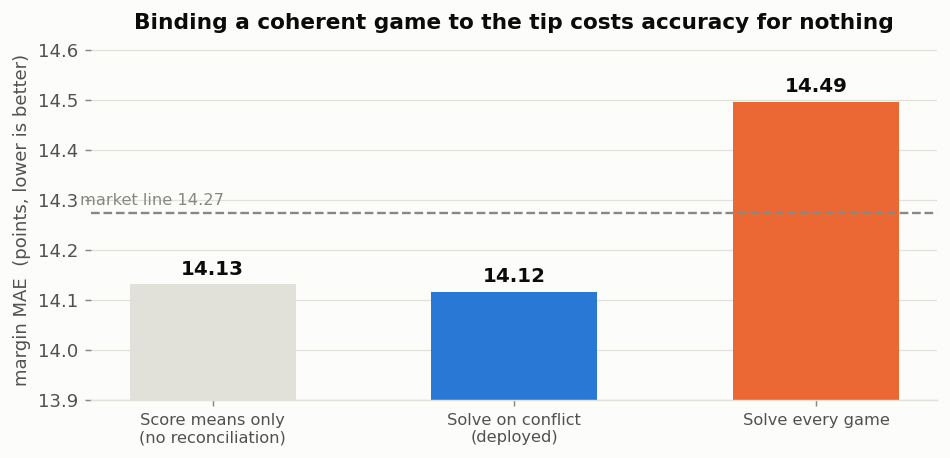

In [11]:
REC = MARGIN["reconciliation"]

# Margin MAE against how hard the coherence constraint binds.
labels = ["Score means only\n(no reconciliation)", "Solve on conflict\n(deployed)",
          "Solve every game"]
maes = [POOLED["margin_mae"], REC["on_conflict_median"]["margin_mae"],
        REC["always_median"]["margin_mae"]]

fig, ax = plt.subplots(figsize=(8.4, 3.6))
ax.bar(range(3), maes, color=[GRID, BLUE, ORANGE], width=0.55, linewidth=0)
for i, v in enumerate(maes):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", color=INK, fontsize=11,
            fontweight="bold")
ax.axhline(POOLED["market_margin_mae"], color=MUTED, linewidth=1.3, linestyle="--")
ax.text(-0.44, POOLED["market_margin_mae"] + 0.018,
        f"market line {POOLED['market_margin_mae']:.2f}", color=MUTED, fontsize=9)
ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(13.9, 14.62)
ax.set_ylabel("margin MAE  (points, lower is better)")
ax.set_title("Binding a coherent game to the tip costs accuracy for nothing")
tidy(ax, xgrid=False, ygrid=True)
plt.show()

print(f"unreconciled      {maes[0]:.2f}")
print(f"solve on conflict {maes[1]:.2f}")
print(f"solve every game  {maes[2]:.2f}")

The calibrated probability is **Tier C**, which carries 100% of the tip (section 10) and
models no scores at all. Binding the score distribution to it hands a scoreline to a
model that has never predicted one. Doing that only where the two models disagree on
the winner keeps the property that matters and drops the cost: margin MAE
**14.49** to **14.12**, and margin
bias from **-1.62** to **-0.53**
points.

### Where it landed

Against the arrangement that predates all of this work:

| Displayed value | Before | Now | Change |
|:--|--:|--:|--:|
| Margin MAE | 14.31 | 14.12 | -0.19 |
| Home score MAE | 10.28 | 9.24 | -1.04 |
| Away score MAE | 9.60 | 8.76 | -0.84 |
| Total MAE | 14.74 | 11.36 | -3.38 |
| Margin CRPS | 10.19 | 10.23 | +0.05 |

Every displayed number is better, the total by more than three points, and CRPS is a
wash (+0.05) against a version that was
+0.31 behind two hours earlier. The coherence properties
survive intact: no step at a margin of zero, a distribution that can be sampled and
quantiled without carrying weights around, and a scoreline that never contradicts the
tip.

### What the transfer actually taught

The thesis argument was right about the mechanism and silent about the dosage. Study 1
says do not correct an object after you generate it, and that held: the reweighting had
a discontinuity in it and could not be sampled. What the argument does not say is *how
much* of the constraint to impose, or which statistic to read off the result, and the
first version of the fix got both wrong while looking principled.

Reading the numbers is what separated them. Three measurements, made in one sitting,
turned a change that cost +0.15 points into one
that gains 0.19. Not one of them needed a new
idea. They needed something in the repository that could say *this got worse*.

---
## 9. One comparison that must not be over-read

The report also shows, on the 576 games with a bookmaker line:

- model CRPS **10.25**
- market line CRPS **14.27**

**This is not a like-for-like comparison and should not be quoted as beating the
market.** The line is a *point* forecast, so its CRPS is simply its MAE. CRPS
penalises any point forecast heavily against a distribution centred in the same
place, because a point forecast claims zero uncertainty.

In [12]:
rng = np.random.default_rng(11)
sigma = 13.0                                   # roughly NRL margin spread
truth = rng.normal(0.0, sigma, size=4_000)
draws = rng.normal(0.0, sigma, size=40_000)    # honest distribution, same centre

as_dist = float(np.mean([dm.crps_ensemble(draws, y) for y in truth]))
as_point = float(np.mean(np.abs(0.0 - truth)))  # same centre, zero spread

print(f"identical centre, scored as a distribution : CRPS {as_dist:5.2f}")
print(f"identical centre, scored as a point        : CRPS {as_point:5.2f}  (= MAE)")
print(f"penalty for being a point forecast         :      {as_point - as_dist:5.2f}")
print("\nSo a distribution 'beating' a point forecast on CRPS is close to automatic.")

identical centre, scored as a distribution : CRPS  7.31
identical centre, scored as a point        : CRPS 10.29  (= MAE)
penalty for being a point forecast         :       2.98

So a distribution 'beating' a point forecast on CRPS is close to automatic.


A genuinely fair test would give the market line the same residual-spread treatment
and score both as distributions. That was deliberately **not** done here: rebuilding
the exact `genuine_oof` row set outside `evaluate.py` risks a subtly non-comparable
number, which is worse than no number. It is queued as future work.

The honest market comparison remains the point one: margin MAE
**14.13** for the model against
**14.27** for the line.

---
## 10. What this actually does to the tips

The honest answer, stated before anything else: **the scoreline work cannot change a
tip, by construction.** After simulating, `predict_match_outcome_and_scoreline_with_bayes`
overwrites the win probabilities from the calibrated conditional:

```python
probabilities["home_win_prob"] = calibrated_cond * non_draw
probabilities["away_win_prob"] = (1.0 - calibrated_cond) * non_draw
home_team_result = "Win" if home_win_prob > away_win_prob else "Loss"
```

Whenever `non_draw > 0` that comparison reduces to `calibrated_cond > 0.5`. The tip is
a function of the calibrated probability and nothing else, so no change to the score
means, the dispersion, `lambda3`, or the reconciliation can flip one. When the change
landed, the held-out accuracy was byte-identical before and after, as it had to be.

This report reads **374/580**, accuracy
0.6448, log loss 0.6327. That is *not* the
before-and-after comparison: the model was retrained after that comparison was made,
so this number reflects new artefacts on the same corpus. The measured effect of the
work in this notebook on tipping accuracy remains exactly zero, and the reason is
worth understanding because it points at where the real headroom is.

### Tier C is the entire tip

| Expert | Accuracy | Log loss | Brier |
|:--|--:|--:|--:|
| Tier A | 61.7% | 0.8407 | 0.2620 |
| Tier B | 62.4% | 0.6877 | 0.2380 |
| Tier C | 64.5% | 0.6322 | 0.2210 |
| **Pooled (what ships)** | **64.5%** | **0.6327** | **0.2213** |

Both probability pools select **Tier C**, the plain binary classifier, and give
Tier A and Tier B **zero weight**:

```text
Market pool nested selection:   tier_c
No-market selected pool weights: tier_a=0.000, tier_b=0.000, tier_c=1.000
```

The pool considered the score models and rejected them. Look at the table: Tier C
is better than Tier B on every measure, and the pooled result equals Tier C's to
four decimals because the pool *is* Tier C.

### So what does the score model do?

Everything above about the score distribution, the Poisson family, `lambda3`, the dispersion, the
100,000 simulated scorelines, the constraint-native reconciliation, feeds the
**predicted margin and scoreline**, not the tip. It is the tie-breaker and the
human-readable detail beside each pick.

That reframes the CRPS finding. "The simulator does not beat a normal
approximation" is a statement about **the quality of the scorelines shown next to
your tips**, not about the tips themselves. It matters for a margin tie-breaker
and for anyone reading the predicted score. It does not decide who you back.

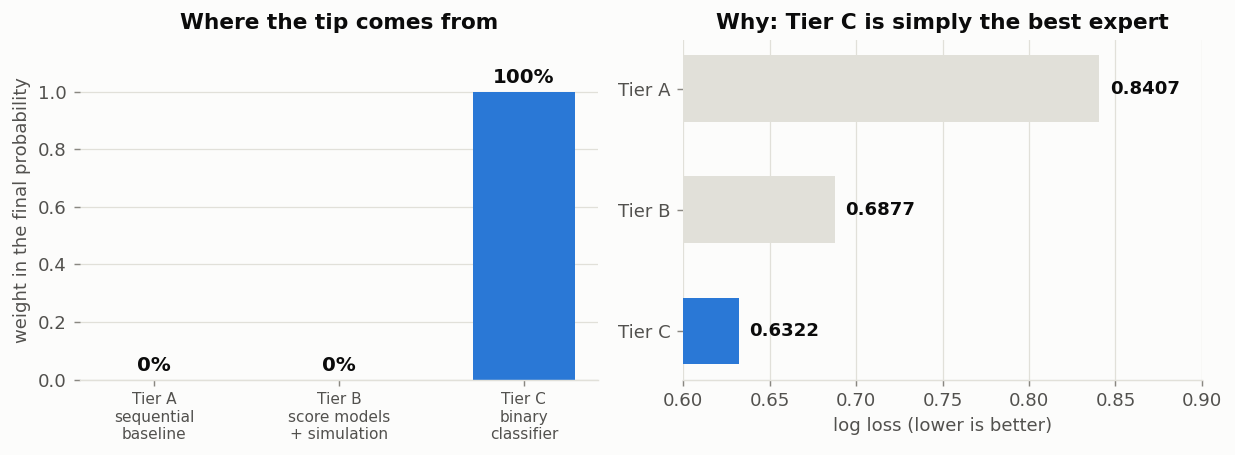

In [13]:
# The pool weights make this concrete: what fraction of the final probability
# does each expert actually carry?
labels = ["Tier A\nsequential\nbaseline", "Tier B\nscore models\n+ simulation", "Tier C\nbinary\nclassifier"]
weights = [0.0, 0.0, 1.0]                       # no-market pool, from the manifest

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))

axes[0].bar(range(3), weights, color=[GRID, GRID, BLUE], width=0.55, linewidth=0)
for i, w in enumerate(weights):
    axes[0].text(i, w + 0.03, f"{w:.0%}", ha="center", color=INK,
                 fontsize=11, fontweight="bold")
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(labels, fontsize=8.5)
axes[0].set_ylim(0, 1.18); axes[0].set_ylabel("weight in the final probability")
axes[0].set_title("Where the tip comes from")
tidy(axes[0], xgrid=False, ygrid=True)

# And where the distributional work lands instead.
experts = ["tier_a", "tier_b", "tier_c"]
lls = [POOLED["expert_metrics"][e]["log_loss"] for e in experts]
axes[1].barh(range(3), lls, color=[GRID, GRID, BLUE], height=0.55, linewidth=0)
for i, v in enumerate(lls):
    axes[1].text(v + 0.006, i, f"{v:.4f}", va="center", color=INK,
                 fontsize=10, fontweight="bold")
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(["Tier A", "Tier B", "Tier C"])
axes[1].set_xlim(0.60, 0.90); axes[1].invert_yaxis()
axes[1].set_xlabel("log loss (lower is better)")
axes[1].set_title("Why: Tier C is simply the best expert")
tidy(axes[1], xgrid=True, ygrid=False)

fig.tight_layout()
plt.show()

### Where the headroom actually is

Tier C is the best-performing component in the system and the only one that
reaches the tip, and it is trained as an afterthought. `train_binary_classifier`
**reuses the score model's hyperparameters** with the objective swapped to
`binary`; it gets no search of its own.

So the highest-value open item for tipping accuracy is not more distributional
machinery. It is giving the one component that decides every tip its own
hyperparameter search, and then using the framework in this notebook to check
whether the result is real.

Section 8 gives that item a second reason to exist. Tier C sets the probability that
every reconciled scoreline is now forced to carry, so the coherence tax measured there
is a direct function of how far Tier C sits from the score models. Tuning Tier C should
buy accuracy in the tips *and* shrink the price of coherence in the scoreline.

That is itself a lesson the evaluation framework delivered. Without per-expert
scoring on identical rows, "the ensemble gets 64%" conceals the
fact that the ensemble is one model and the other two are decoration.

<div style="height:1px"></div>

> **A caution on attribution.** The project's Notion page previously recorded
> 61.9% accuracy, and this report reads 64.5%. **That gain is not
> from this work.** It came from the data backfill to 2008 and the new feature
> families, and from the retrain that followed, all of which sit outside this
> notebook's changes. The corpus changed, so the two numbers are not strictly
> comparable anyway. The measured effect of everything in this notebook on
> tipping accuracy is exactly zero; what it bought was the ability to see what
> the model is doing, two correctness fixes, and one measured trade-off.

---
## 11. What this gives the PhD back

The transfer is not one-directional.

**A second domain where the metric suite produced honest negatives.** Study 1's
headline contribution is the evaluation framework and the negative results it
surfaced, not a claim of universal superiority. That framework has now been applied
to a completely unrelated problem, sport prediction rather than water consumption
reconstruction, and it did the same job: it found that the elaborate model does not
beat the simple baseline, and it quantified a cost that had been assumed away. **A
framework that only produces honest negatives on the dataset it was designed for is
a dataset artefact. One that does it on an unrelated domain is a method.**

**The point-versus-distributional role split replicated exactly.** In Study 1, point
accuracy was a wash while the distributional roles separated the methods. Here, the
margin MAE spread across methods is small while CRPS, coverage, and PIT rank them
clearly and disagree with each other. Same structure, different domain.

**Constraint-native beats projection, again.** Study 1 diagnosed per-step projection
as contracting the posterior, and proposed constraint-native parameterisation as the
structural fix, currently future work. Footy Tipper is now a **worked instance of
that argument**: a reconciliation-after-the-fact was replaced by solving inside the
constraint, and the failure mode it eliminated (a special case for an unreachable
state) is concrete evidence for the general claim. That is a citable illustration
that the projection-versus-native distinction is not specific to the simplex.

**One thing footy-tipper does better than the Study 0 literature.** Study 0 surveys
domain-adaptation methods for structural regime asymmetry. Footy Tipper handles its
own structural missingness, matches with and without bookmaker odds, by **training
two separate pools and routing between them**, never imputing a neutral 0.5. It also
scores the model-only path counterfactually on every held-out row, so sparse odds
coverage cannot hide a weak fallback. That is a cleaner answer to "the source and
target have different information content" than feature alignment, and it is worth a
paragraph in the Study 0 discussion as a deployed alternative to adaptation.

---
## 12. What is next

**The highest-value item is not on this list.** Per section 10, it is giving Tier C
its own hyperparameter search, because Tier C is the only expert that reaches the
tip and it currently inherits the score model's parameters.

Below are the two further *thesis* transfers, scoped and deliberately not built,
pending what section 7 says about whether the score model deserves more investment.

**Study 0 port: a season-out degradation curve.** Train on seasons `< Y`, test on
`Y`, `Y+1`, `Y+2`, and plot skill against regime distance. This is Study 0's
degradation-curve logic with "temporal information removed" swapped for "seasons of
drift". It answers two live questions: how far back the training corpus should reach
(a backfill to 2008 just landed), and whether Tier A's `carryover`, the *only*
adaptation mechanism in the codebase, is set anywhere near right. Note that the
cross-validator tunes hyperparameters on **within-season interpolation** while
deployment is **next-season extrapolation**: precisely the regime-asymmetry blind
spot Study 0 exists to measure.

**Sampling the lineup instead of jittering it.** Lineup uncertainty is currently
collapsed to a scalar `E[p(1-p)]` and applied as a lognormal jitter on the score
means, scaled by an **unlearned constant, 0.12**. The thesis move is to sample the
*object*: draw K plausible lineups from the existing shrunk selection-probability
table, rebuild the role-group features for each, push each through Tier B, and
average. That is genuine marginalisation over a latent discrete object rather than
noise on an aggregate, and it would let the magic number be replaced by something
measured.

---

### Summary

| | |
|:--|:--|
| **Ported** | CRPS, randomised PIT, coverage-with-width, strong-baseline discipline, constraint-native reconciliation |
| **Rejected** | The diffusion itself, energy/variogram, zero-inflation, constraint projection, clustering |
| **Found** | The simulator does not beat a normal approximation; `lambda3` is zero; dispersion is ~5x Poisson; coherence costs CRPS; **Tier C carries 100% of the tip** |
| **Fixed** | A train/serve skew in the meta-layer, in both `train.py` and `evaluate.py` |
| **Effect on tips** | **Zero.** Identical accuracy, log loss and Brier. This work bought measurement and correctness, not accuracy |
| **Next lever** | Tune Tier C on its own objective; it decides every tip and has never been tuned for it |
| **Verdict** | The model was a dud. **The methodology was the transfer.** |

*Regenerate with `python research/build_phd_transfer_notebook.py`.*